<a href="https://colab.research.google.com/github/vanadhisivakumar-source/Fundamental-Data-Science-Analytics-projects/blob/main/cross%20validation%20with%20linear%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

381
164


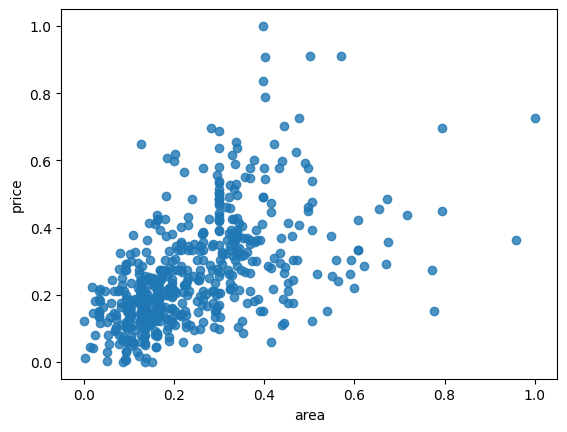

In [10]:
# import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sklearn
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import scale
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
import warnings # supress warnings
warnings.filterwarnings('ignore')

# Path to the zip file
zip_file_path = '/content/archive (1).zip'

# Name of the CSV file within the zip archive
csv_file_name = 'Housing.csv'

# Create a ZipFile object
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Extract a specific file from the zip archive
    zip_ref.extract(csv_file_name, '/tmp/') # Extract to a temporary directory

# Read the extracted CSV file into a pandas DataFrame
housing = pd.read_csv(f'/tmp/{csv_file_name}')

housing.head()

# number of observations
len(housing.index)
# filter only area and price
df = housing.loc[:, ['area', 'price']]
df.head()
# recaling the variables (both)
df_columns = df.columns
scaler = MinMaxScaler()
df = scaler.fit_transform(df)
# rename columns (since now its an np array)
df = pd.DataFrame(df)
df.columns = df_columns
df.head()
# visualise area-price relationship
sns.regplot(x="area", y="price", data=df, fit_reg=False)

# split into train and test
df_train, df_test = train_test_split(df,
train_size = 0.7,
test_size = 0.3,
random_state = 10)

print(len(df_train))
print(len(df_test))

# split into X and y for both train and test sets
# reshaping is required since sklearn requires the data to be in shape
# (n, 1), not as a series of shape (n, )
X_train = df_train['area'].values.reshape(-1, 1)
y_train = df_train['price']
X_test = df_test['area'].values.reshape(-1, 1)
y_test = df_test['price']

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
lr = LinearRegression()

# Train the model using the training data
lr.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


Now that the model is trained, let's make predictions on the test set and evaluate its performance.

Mean Squared Error (MSE): 0.0164
R-squared (R2): 0.2484


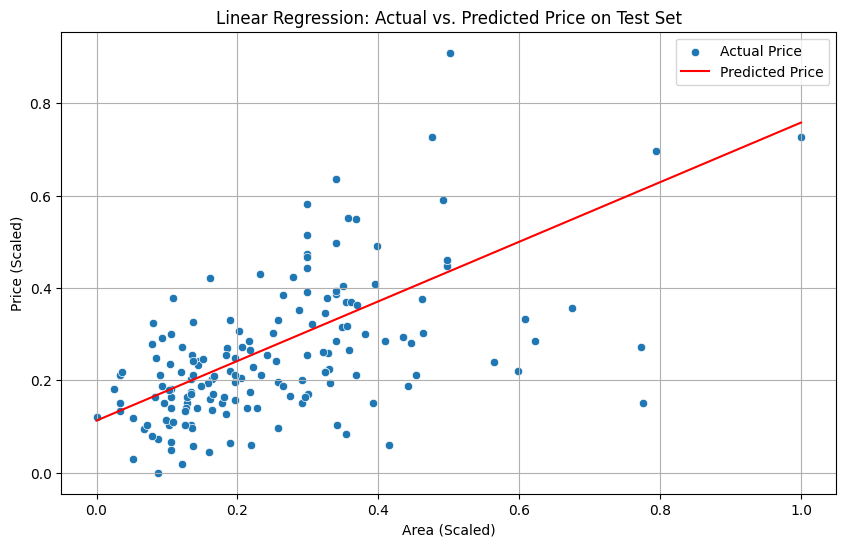

In [12]:
# Make predictions on the test set
y_pred = lr.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Plot the regression line and scatter plot for test data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test.flatten(), y=y_test, label='Actual Price')
sns.lineplot(x=X_test.flatten(), y=y_pred, color='red', label='Predicted Price')
plt.title('Linear Regression: Actual vs. Predicted Price on Test Set')
plt.xlabel('Area (Scaled)')
plt.ylabel('Price (Scaled)')
plt.legend()
plt.grid(True)
plt.show()